BƯỚC 0: KIỂM TRA DỮ LIỆU GỐC
Số mẫu: 20 | y_min=85 ml | y_max=276 ml | y_mean=189.3 ml


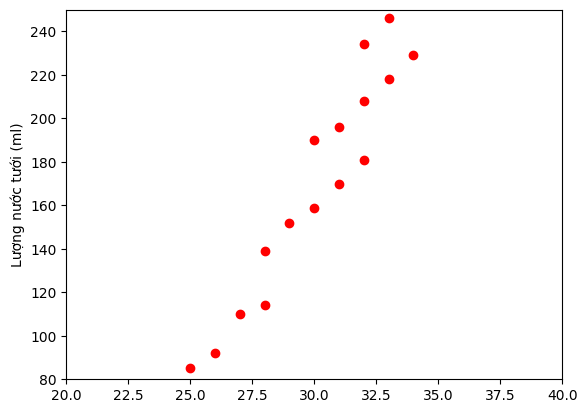


BƯỚC 1: TIỀN XỬ LÝ DỮ LIỆU
Sau lọc: 20 mẫu hợp lệ

Shape X_train_b: (16, 5)
Tham số chuẩn hóa:
  nhiệt_độ: mean=31.6875, std=2.6153
  ẩm_kk: mean=58.3750, std=6.1020
  ẩm_đất: mean=37.8750, std=6.7996
  giai_đoạn: mean=2.8125, std=1.0136
  y:  mean=199.7500, std=52.0090

BƯỚC 2: KHỞI TẠO MÔ HÌNH
Số tham số: 5 | alpha=0.001
theta khởi tạo: [0. 0. 0. 0. 0.]

Cost ban đầu:      0.500000
Cost sau 1 bước:   0.496226
=> Cost giảm => oke

BƯỚC 3: HUẤN LUYỆN
Epoch     0 | cost = 0.49622592
Epoch   500 | cost = 0.01308526
Epoch  1000 | cost = 0.00201545
Epoch  1500 | cost = 0.00148946
Epoch  2000 | cost = 0.00124362
Epoch  2500 | cost = 0.00104237
Epoch  3000 | cost = 0.00087418
Epoch  3500 | cost = 0.00073354
Epoch  4000 | cost = 0.00061594
Epoch  4500 | cost = 0.00051761
Epoch  5000 | cost = 0.00043538
Epoch  5500 | cost = 0.00036663
Epoch  6000 | cost = 0.00030913
Epoch  6500 | cost = 0.00026105
Epoch  7000 | cost = 0.00022085
Epoch  7500 | cost = 0.00018723

Huấn luyện hoàn tất. Cost cuối:

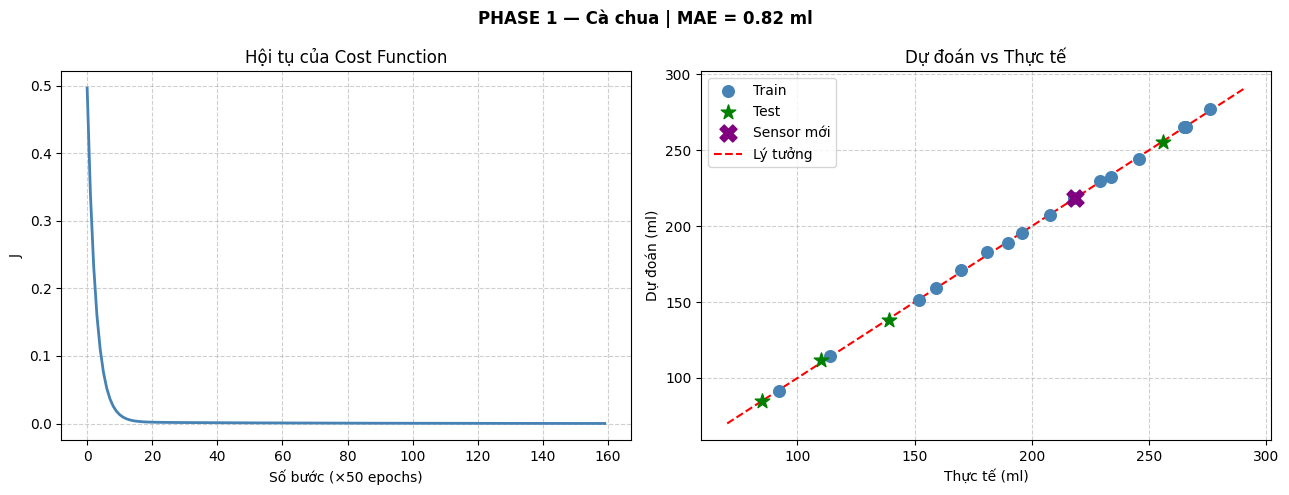

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


# BƯỚC 0: DỮ LIỆU CÀ CHUA (giả lập)
X_raw = np.array([
    [25, 70, 55, 1],
    [27, 65, 50, 1],
    [28, 68, 48, 1],
    [26, 72, 52, 1],
    [29, 63, 45, 2],
    [31, 60, 42, 2],
    [30, 62, 44, 2],
    [32, 58, 40, 2],
    [31, 61, 38, 3],
    [33, 56, 35, 3],
    [34, 54, 33, 3],
    [32, 59, 36, 3],
    [33, 55, 32, 4],
    [35, 50, 30, 4],
    [36, 48, 28, 4],
    [34, 52, 31, 4],
    [35, 51, 29, 4],
    [28, 66, 47, 2],
    [30, 60, 40, 3],
    [32, 57, 34, 4],
])

def calc_y(row):
    t, kk, dat, gd = row
    return int(round(180 + 4*(t-30) - 1.5*(kk-60) - 2*(dat-40) + 20*(gd-2.5)))

y_raw = np.array([calc_y(r) for r in X_raw])

print("=" * 55)
print("BƯỚC 0: KIỂM TRA DỮ LIỆU GỐC")
print("=" * 55)
print(f"Số mẫu: {len(y_raw)} | y_min={y_raw.min()} ml | y_max={y_raw.max()} ml | y_mean={y_raw.mean():.1f} ml")

plt.plot(X_raw[:, 0], y_raw, 'ro')
plt.axis([20, 40, 80, 250])
plt.ylabel('Lượng nước tưới (ml)')
plt.show()


# BƯỚC 1: TIỀN XỬ LÝ DỮ LIỆU
print("\n" + "=" * 55)
print("BƯỚC 1: TIỀN XỬ LÝ DỮ LIỆU")
print("=" * 55)

mask = (
    (X_raw[:, 0] >= 0)  & (X_raw[:, 0] <= 40) &
    (X_raw[:, 1] >= 20) & (X_raw[:, 1] <= 100) &
    (X_raw[:, 2] >= 10) & (X_raw[:, 2] <= 90)
)
X_clean = X_raw[mask]
y_clean = y_raw[mask]
print(f"Sau lọc: {len(y_clean)} mẫu hợp lệ")

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

X_mean = np.mean(X_train, axis=0)
X_std  = np.std(X_train, axis=0)
y_mean = np.mean(y_train)
y_std  = np.std(y_train)

X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled  = (X_test  - X_mean) / X_std
y_train_scaled = (y_train - y_mean) / y_std
y_test_scaled  = (y_test  - y_mean) / y_std

X_train_b = np.column_stack([np.ones(len(X_train_scaled)), X_train_scaled])
X_test_b  = np.column_stack([np.ones(len(X_test_scaled)),  X_test_scaled])

print(f"\nShape X_train_b: {X_train_b.shape}")
print("Tham số chuẩn hóa:")
feature_names = ['nhiệt_độ', 'ẩm_kk', 'ẩm_đất', 'giai_đoạn']
for n, m, s in zip(feature_names, X_mean, X_std):
    print(f"  {n}: mean={m:.4f}, std={s:.4f}")
print(f"  y:  mean={y_mean:.4f}, std={y_std:.4f}")


# BƯỚC 2: KHỞI TẠO MÔ HÌNH
print("\n" + "=" * 55)
print("BƯỚC 2: KHỞI TẠO MÔ HÌNH")
print("=" * 55)

n = X_train_b.shape[1]
theta = np.zeros(n)
alpha = 0.001
print(f"Số tham số: {n} | alpha={alpha}")
print(f"theta khởi tạo: {theta}")


def compute_cost_vectorized(X_b, y, theta):
    m = len(y)
    error = X_b @ theta - y
    return (1 / (2 * m)) * np.dot(error, error)

def compute_gradient(X_b, y, theta):
    m = len(y)
    error = X_b @ theta - y
    return (1 / m) * (X_b.T @ error)

def adaptive_learning_step(X_b, y, theta, alpha):
    gradient = compute_gradient(X_b, y, theta)
    return theta - alpha * gradient

def evaluate_metrics(y_true, y_pred):
    error = y_pred - y_true
    mae  = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error ** 2))
    return mae, rmse


cost_bandau = compute_cost_vectorized(X_train_b, y_train_scaled, theta)
theta_test = adaptive_learning_step(X_train_b, y_train_scaled, theta, alpha)
cost_after1 = compute_cost_vectorized(X_train_b, y_train_scaled, theta_test)
print(f"\nCost ban đầu:      {cost_bandau:.6f}")
print(f"Cost sau 1 bước:   {cost_after1:.6f}")
print(f"=> Cost {'giảm => oke' if cost_after1 < cost_bandau else 'TĂNG => giảm alpha'}")


# BƯỚC 3: HUẤN LUYỆN
print("\n" + "=" * 55)
print("BƯỚC 3: HUẤN LUYỆN")
print("=" * 55)

theta = np.zeros(n)
epochs = 8000
j_history = []

for epoch in range(epochs):
    theta = adaptive_learning_step(X_train_b, y_train_scaled, theta, alpha)
    cost  = compute_cost_vectorized(X_train_b, y_train_scaled, theta)
    j_history.append(cost)
    if epoch % 500 == 0:
        print(f"Epoch {epoch:5d} | cost = {cost:.8f}")

print(f"\nHuấn luyện hoàn tất. Cost cuối: {j_history[-1]:.8f}")
print("\nTheta sau huấn luyện:")
for name, value in zip(['bias', 'nhiệt_độ', 'ẩm_kk', 'ẩm_đất', 'giai_đoạn'], theta):
    sign = "+" if value >= 0 else ""
    print(f"  theta[{name:12s}] = {sign}{value:.4f}")


print("\n" + "=" * 55)
print("ĐÁNH GIÁ TRÊN TẬP TEST")
print("=" * 55)

y_pred_scaled = X_test_b @ theta
y_pred_real   = y_pred_scaled * y_std + y_mean
y_test_real   = y_test_scaled * y_std + y_mean

mae_test, rmse_test = evaluate_metrics(y_test_real, y_pred_real)
print(f"MAE  = {mae_test:.2f} ml")
print(f"RMSE = {rmse_test:.2f} ml")
print(f"Đánh giá: {'ĐẠT TIÊU CHUẨN' if mae_test < 8 else 'CẦN CẢI THIỆN'}")

print("\n--- CHI TIẾT ---")
gd_names = {1:"non", 2:"phát triển", 3:"ra hoa", 4:"chín"}
for i in range(len(y_test_real)):
    r = X_test[i]
    print(f"  {r[0]}°C | KK={r[1]}% | đất={r[2]}% | {gd_names[r[3]]}")
    print(f"    -> Dự đoán: {y_pred_real[i]:.1f} ml | Thực tế: {y_test_real[i]:.1f} ml")


print("\n" + "=" * 55)
print("DỰ ĐOÁN VỚI SENSOR MỚI")
print("=" * 55)

sensor = np.array([33, 56, 35, 3])
sensor_scaled = (sensor - X_mean) / X_std
sensor_b = np.insert(sensor_scaled, 0, 1)
pred = (sensor_b @ theta) * y_std + y_mean

print(f"Sensor: {sensor[0]}°C | KK={sensor[1]}% | đất={sensor[2]}% | {gd_names[sensor[3]]}")
print(f"-> quyết định tưới: {pred:.1f} ml")


# TRỰC QUAN HÓA KẾT QUẢ. 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Biểu đồ 1: Cost function
axes[0].plot(j_history[::50], color='steelblue', linewidth=2)
axes[0].set_xlabel("Số bước (×50 epochs)")
axes[0].set_ylabel("J")
axes[0].set_title("Hội tụ của Cost Function")
axes[0].grid(True, linestyle='--', alpha=0.6)

# Biểu đồ 2: Dự đoán vs Thực tế
y_train_pred_real = (X_train_b @ theta) * y_std + y_mean 
y_train_real_vals = y_train_scaled * y_std + y_mean   

axes[1].scatter(y_train_real_vals, y_train_pred_real, color='steelblue', s=70, label='Train', zorder=3)
axes[1].scatter(y_test_real, y_pred_real, color='green', s=120, marker='*', label='Test', zorder=4)
axes[1].scatter(pred, pred, color='purple', s=150, marker='X', label='Sensor mới', zorder=5)

vals = np.concatenate([y_train_real_vals, y_test_real])
lo, hi = vals.min() - 15, vals.max() + 15 
axes[1].plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Lý tưởng')

axes[1].set_xlabel("Thực tế (ml)")
axes[1].set_ylabel("Dự đoán (ml)")
axes[1].set_title("Dự đoán vs Thực tế")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.suptitle("PHASE 1 — Cà chua | MAE = {:.2f} ml".format(mae_test), fontweight='bold')
plt.tight_layout()
plt.savefig('phase1_result.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# PHASE 2: ONLINE LEARNING — MÔ PHỎNG TƯỚI

def feedback_update(x_b, y_actual_scaled, theta, alpha):
    error = np.dot(x_b, theta) - y_actual_scaled
    gradient = error * x_b
    return theta - alpha * gradient

lan_tuoi = 0
error_history = []

while True:
    print(f"\n{'='*45}")
    print(f"LẦN TƯỚI {lan_tuoi + 1}:")
    print(f"{'='*45}")
    print("Nhập dữ liệu từ sensor (giả lập):")

    x_new_data = []
    nhiet_do = float(input("  Nhiệt độ (C): "))
    x_new_data.append(nhiet_do)

    for feature in ['Độ ẩm không khí (%)', 'Độ ẩm đất trước tưới (%)', 'Giai đoạn sinh trưởng (1-4)']:
        value = float(input(f"  {feature}: "))
        x_new_data.append(value)

    x_new_data = np.array(x_new_data)
    x_new_data_scaled = (x_new_data - X_mean) / X_std

    x_new_data_bias = np.insert(x_new_data_scaled, 0, 1)

    y_predict_scaled = np.dot(x_new_data_bias, theta)
    y_predict = y_predict_scaled * y_std + y_mean
    print(f"\n->lượng nước dự đoán quyết định tưới: {y_predict:.1f} ml")

    am_dat_sau_tuoi = float(input("  Đo độ ẩm đất sau tưới (%): "))
    do_lech_am_dat = am_dat_sau_tuoi - x_new_data[2]
    print(f"  Độ lệch ẩm đất (sau - trước): {do_lech_am_dat:.1f}%")

    y_actual = do_lech_am_dat * 5 * 3
    y_actual_scaled = (y_actual - y_mean) / y_std

    error_ml = abs(y_predict - y_actual)
    error_history.append(error_ml)
    print(f"  Lượng nước thực tế cây cần: {y_actual:.1f} ml")
    print(f"  Sai số lần này: {error_ml:.1f} ml")

    theta = feedback_update(x_new_data_bias, y_actual_scaled, theta, alpha)
    print(f"  Theta sau cập nhật: {np.round(theta, 4)}")

    print(f"\n--- Lịch sử sai số ---")
    for i, e in enumerate(error_history):
        print(f"  Lần tưới {i+1}: {e:.1f} ml")

    lan_tuoi += 1


LẦN TƯỚI 1:
Nhập dữ liệu từ sensor (giả lập):

->lượng nước dự đoán quyết định tưới: 89.1 ml
  Độ lệch ẩm đất (sau - trước): 5.0%
  Lượng nước thực tế cây cần: 75.0 ml
  Sai số lần này: 14.1 ml
  Theta sau cập nhật: [-0.0037  0.1937 -0.2098 -0.2722  0.3479]

--- Lịch sử sai số ---
  Lần tưới 1: 14.1 ml

LẦN TƯỚI 2:
Nhập dữ liệu từ sensor (giả lập):

->lượng nước dự đoán quyết định tưới: 171.2 ml
  Độ lệch ẩm đất (sau - trước): 8.0%
  Lượng nước thực tế cây cần: 120.0 ml
  Sai số lần này: 51.2 ml
  Theta sau cập nhật: [-0.0047  0.1943 -0.2101 -0.2725  0.3487]

--- Lịch sử sai số ---
  Lần tưới 1: 14.1 ml
  Lần tưới 2: 51.2 ml

LẦN TƯỚI 3:
Nhập dữ liệu từ sensor (giả lập):

->lượng nước dự đoán quyết định tưới: 228.0 ml
  Độ lệch ẩm đất (sau - trước): 12.0%
  Lượng nước thực tế cây cần: 180.0 ml
  Sai số lần này: 48.0 ml
  Theta sau cập nhật: [-0.0056  0.1935 -0.2096 -0.2718  0.3485]

--- Lịch sử sai số ---
  Lần tưới 1: 14.1 ml
  Lần tưới 2: 51.2 ml
  Lần tưới 3: 48.0 ml

LẦN TƯỚI 4:
N

ValueError: could not convert string to float: ''